# Track-Level Classification of Radar Point Clouds via Multi-Frame Accumulation

**N = 20, all sensors.** RadarScenes point-cloud object classification (5 classes: `car`,
`large_vehicle`, `two_wheeler`, `pedestrian`, `pedestrian_group`), extended from
single-scan to multi-scan (track-level) accumulation.

This notebook documents one branch (`N=20`, all 4 sensors) of a larger architecture/
feature study. All numbers below are single fixed-split results (sequence-grouped
train/val/test, canonical split reused across every experiment), not fold-averaged
unless stated. Source: `track_accumulation.md` in the project repo, plus new results
computed for this notebook (Sections 4 and 6).

## 1. Motivation: why accumulate N frames

- A single RadarScenes detection instance (one object, one scan) averages **~2.9
  points**. Five-class separation from that few points hits a hard ceiling regardless
  of encoder: histograms, explicit per-instance statistics, combined feature stacks,
  and a learned point-set network (DeepReflecs) all converge to the same macro F1
  band on single-scan data. The bottleneck is point count, not representation.
- A `track_id` is a stable ground-truth identity that persists across many scans (and,
  in RadarScenes, across sensor handoffs). Pooling a track's own points over several
  scans is a free way to increase the effective point count per classification
  decision, without needing more sensors or higher resolution.
- Two independent hypotheses for *why* this should help:
  1. **Denoising**: more points per decision reduces variance of the same
     per-instance summary statistics (RCS level, velocity spread, spatial extent).
  2. **Temporal structure**: scan-to-scan dynamics (micro-Doppler stability, RCS
     fluctuation) might carry class information a single scan cannot expose at all
     (e.g. a pedestrian's limb motion vs. a car's rigid-body motion).
- Both are tested directly in this notebook. Sections 3-4 isolate (1) from (2);
  the answer, established empirically, favors (1) far more than (2).
- Deployment constraint carried through every design choice below: the classifier
  must run **causally and in real time** on an automotive SoC, one scan at a time,
  with bounded memory. A decision at scan *t* may only use scans up to and including
  *t*. This rules out any non-causal (bidirectional) sequence model and motivates the
  fixed-size FIFO buffer described in Section 2.

## 2. Streaming buffer, cross-sensor handoff, and coordinate frame

### 2.1 Why cross-sensor, not just more time on one sensor

RadarScenes covers a scene with **4 radar sensors** with overlapping fields of view.
A `track_id` is a stable identity *across* sensors, not per-sensor: a tracked object
is frequently seen by 2-3 different sensors over its lifetime as it moves through the
scene. All 4 sensors share one global clock (verified: overlapping timestamp ranges,
same units, zero exact-timestamp collisions across sensors within a sequence).

Consequence: building a track's window by sorting **all** of that track's detections
(regardless of which sensor produced them) by timestamp, instead of filtering to one
sensor, gives more real detections per track without needing more real time to pass.
This is a *different* lever from increasing window length `N`, and the two stack
(Section 8): cross-sensor handoff at `N=20` beat single-sensor accumulation pushed to
`N=50`.

Symmetric rule, train and inference: a window is built from whichever sensor(s) are
actually detecting the track *right now*. No enriched multi-sensor training against a
sensor-restricted inference reality.

### 2.2 The streaming buffer

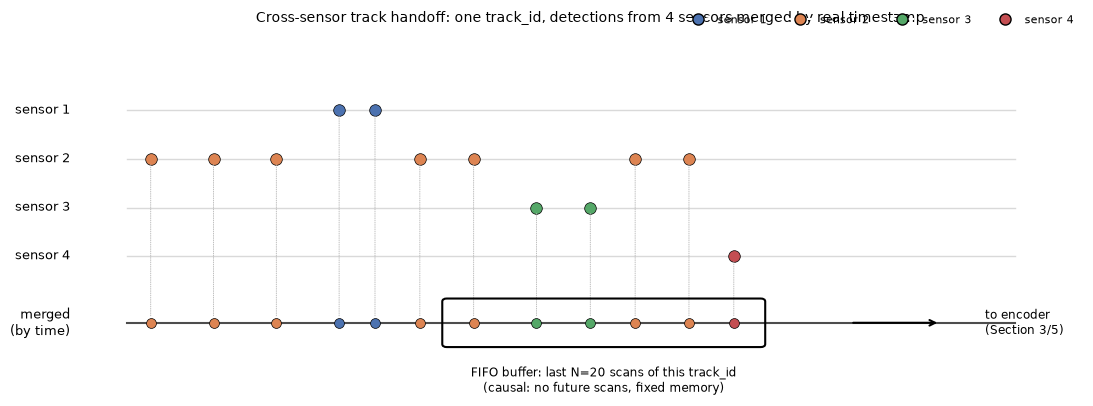

In [1]:

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

fig, ax = plt.subplots(figsize=(11, 4.2))
ax.set_xlim(0, 11)
ax.set_ylim(0, 5)
ax.axis("off")

sensor_y = {1: 4.0, 2: 3.2, 3: 2.4, 4: 1.6}
colors = {1: "#4C72B0", 2: "#DD8452", 3: "#55A868", 4: "#C44E52"}

# detections for one track_id, interleaved across sensors, sorted by real time
detections = [
    (0.6, 2), (1.3, 2), (2.0, 2), (2.7, 1), (3.1, 1), (3.6, 2),
    (4.2, 2), (4.9, 3), (5.5, 3), (6.0, 2), (6.6, 2), (7.1, 4),
]

for s, y in sensor_y.items():
    ax.text(-0.3, y, f"sensor {s}", ha="right", va="center", fontsize=9)
    ax.axhline(y, xmin=0.03, xmax=0.93, color="0.85", lw=1, zorder=0)

for t, s in detections:
    ax.scatter([t], [sensor_y[s]], color=colors[s], s=70, zorder=3, edgecolor="k", linewidth=0.5)

# merged causal timeline (bottom), sorted purely by timestamp across all sensors
merged_y = 0.5
ax.axhline(merged_y, xmin=0.03, xmax=0.93, color="0.3", lw=1.5, zorder=1)
for i, (t, s) in enumerate(detections):
    ax.scatter([t], [merged_y], color=colors[s], s=50, zorder=3, edgecolor="k", linewidth=0.5)
    ax.annotate("", xy=(t, merged_y + 0.05), xytext=(t, sensor_y[s] - 0.05),
                arrowprops=dict(arrowstyle="-", color="0.7", lw=0.6, linestyle=":"))
ax.text(-0.3, merged_y, "merged\n(by time)", ha="right", va="center", fontsize=9)

# FIFO buffer window over the last N=20 (drawn as last 6 for space) scans of the track
buf_start, buf_end = detections[-6][0] - 0.3, detections[-1][0] + 0.3
ax.add_patch(mpatches.FancyBboxPatch((buf_start, merged_y - 0.35), buf_end - buf_start, 0.7,
                                       boxstyle="round,pad=0.05", linewidth=1.5,
                                       edgecolor="k", facecolor="none", zorder=4))
ax.text((buf_start + buf_end) / 2, merged_y - 0.7, "FIFO buffer: last N=20 scans of this track_id\n(causal: no future scans, fixed memory)",
        ha="center", va="top", fontsize=8.5)

ax.annotate("", xy=(9.4, merged_y), xytext=(8.4, merged_y),
            arrowprops=dict(arrowstyle="->", color="k", lw=1.5))
ax.text(9.9, merged_y, "to encoder\n(Section 3/5)", ha="left", va="center", fontsize=8.5)

legend_handles = [Line2D([0], [0], marker="o", color="w", markerfacecolor=c, markeredgecolor="k",
                          markersize=8, label=f"sensor {s}") for s, c in colors.items()]
ax.legend(handles=legend_handles, loc="upper right", ncol=4, frameon=False, fontsize=8,
          bbox_to_anchor=(1.0, 1.15))
ax.set_title("Cross-sensor track handoff: one track_id, detections from 4 sensors merged by real timestamp",
             fontsize=10, pad=20)
fig.tight_layout()
plt.show()


### 2.3 Coordinate frame: why `x_seq`/`y_seq`, not `x_cc` or raw `x_rel`

Three candidate frames, in the order they matter for pooling points across scans:

| frame | definition | usable across scans? |
|---|---|---|
| `x_cc`/`y_cc` | ego (car) frame, origin at rear axle | **No.** Shifts with ego motion every measurement; concatenating points from different scans mixes different, shifted frames. |
| `x_seq`/`y_seq` | dataset's global-sequence frame, odometry-corrected | Removes ego motion, but **not** the tracked object's own translation across the window. |
| `x_rel`/`y_rel` | `x_seq`/`y_seq`, recentered on *that scan's own* object centroid | **Yes**, the actual model input. Bounded scan-to-scan (verified on a worked example: position relative to the object's *first* detection drifts monotonically over ~8 scans; relative to *that scan's own* centroid stays within ~±1 m). |

`x_seq`/`y_seq` is not a whiteboard optimization, it is the **required base frame**:
`x_rel`/`y_rel` cannot be computed without it (each scan needs its own centroid
computed in a frame where ego motion has already been removed). Global-fixed
(`x_seq`/`y_seq`) and object-centered (`x_rel`/`y_rel`) are two orthogonal fixes for
two different sources of drift; only doing the first and pooling raw would still let
the tracked object's own translation smear the accumulated point cloud.

Exact calculation, per scan, grouped by (track, scan):

```
x_rel = x_seq - mean(x_seq within that scan's instance)
y_rel = y_seq - mean(y_seq within that scan's instance)
```

i.e. the centroid is recomputed independently for every scan in the window, not
fixed once at the start of the track. That is what keeps `x_rel`/`y_rel` bounded
scan-to-scan instead of drifting: each scan subtracts its own mean, so only the
object's *shape* around its instantaneous centroid survives, not its accumulated
path.

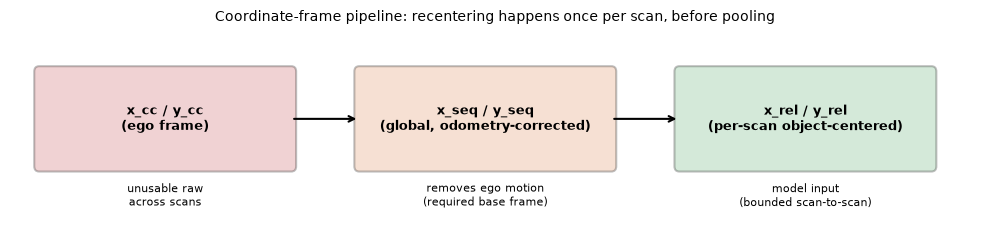

In [2]:

fig, ax = plt.subplots(figsize=(10, 2.6))
ax.set_xlim(0, 10)
ax.set_ylim(0, 2)
ax.axis("off")

boxes = [
    (0.3, "x_cc / y_cc\n(ego frame)", "#C44E52", "unusable raw\nacross scans"),
    (3.6, "x_seq / y_seq\n(global, odometry-corrected)", "#DD8452", "removes ego motion\n(required base frame)"),
    (6.9, "x_rel / y_rel\n(per-scan object-centered)", "#55A868", "model input\n(bounded scan-to-scan)"),
]
w, h = 2.6, 0.9
for x, label, color, note in boxes:
    ax.add_patch(mpatches.FancyBboxPatch((x, 0.7), w, h, boxstyle="round,pad=0.05",
                                           linewidth=1.5, edgecolor="k", facecolor=color, alpha=0.25))
    ax.text(x + w / 2, 0.7 + h / 2, label, ha="center", va="center", fontsize=9, fontweight="bold")
    ax.text(x + w / 2, 0.55, note, ha="center", va="top", fontsize=8)

for x1, x2 in [(0.3 + w, 3.6), (3.6 + w, 6.9)]:
    ax.annotate("", xy=(x2, 0.7 + h / 2), xytext=(x1, 0.7 + h / 2),
                arrowprops=dict(arrowstyle="->", color="k", lw=1.5))

ax.set_title("Coordinate-frame pipeline: recentering happens once per scan, before pooling", fontsize=10)
fig.tight_layout()
plt.show()


## 3. Encoder: DeepReflecs, and the naive pooling baseline

### 3.1 DeepReflecs architecture

Per-point shared-weight network (PointNet-style: every point processed by the same
small MLP, order-independent by construction), operating directly on the raw point
set (5 features per point: `x_rel`, `y_rel`, `rcs`, `vr_compensated`, `range_sc`):

1. **Shared per-point layer 1** (`CONV_DIM=16`): `Linear + ReLU`, applied to every
   point independently.
2. **Global context layer**: injects a permutation-invariant summary (mean/max over
   the point set) back into every point's own feature vector, giving each point
   access to set-level context before the next per-point layer.
3. **Shared per-point layer 2** (`POINT_DIM=32`): `Linear + ReLU`, same
   per-point-independent structure.
4. **Masked global max-pool**: reduces the (variable-length, padded) point set to one
   fixed 32-dim vector, one value per channel, the channel's maximum across all real
   (non-padded) points.
5. **Classification head**: `Linear` to 5 class logits.

Order-invariant and length-invariant by construction (mask handles padding), the
right inductive bias for an unordered radar point cloud.

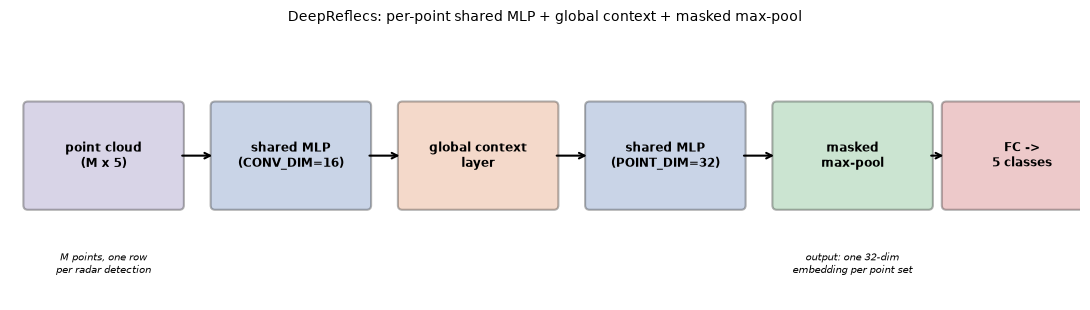

In [3]:

fig, ax = plt.subplots(figsize=(11, 3.2))
ax.set_xlim(0, 12)
ax.set_ylim(0, 3)
ax.axis("off")

stages = [
    (0.2, 1.6, "point cloud\n(M x 5)", "#8172B2"),
    (2.3, 1.6, "shared MLP\n(CONV_DIM=16)", "#4C72B0"),
    (4.4, 1.6, "global context\nlayer", "#DD8452"),
    (6.5, 1.6, "shared MLP\n(POINT_DIM=32)", "#4C72B0"),
    (8.6, 1.6, "masked\nmax-pool", "#55A868"),
    (10.5, 1.6, "FC ->\n5 classes", "#C44E52"),
]
w, h = 1.7, 1.1
for x, y, label, color in stages:
    ax.add_patch(mpatches.FancyBboxPatch((x, y - h/2), w, h, boxstyle="round,pad=0.05",
                                           linewidth=1.5, edgecolor="k", facecolor=color, alpha=0.3))
    ax.text(x + w/2, y, label, ha="center", va="center", fontsize=8.5, fontweight="bold")

for i in range(len(stages) - 1):
    x1 = stages[i][0] + w
    x2 = stages[i + 1][0]
    ax.annotate("", xy=(x2, 1.6), xytext=(x1, 1.6), arrowprops=dict(arrowstyle="->", color="k", lw=1.5))

ax.text(0.2 + w/2, 0.3, "M points, one row\nper radar detection", ha="center", fontsize=7.5, style="italic")
ax.text(8.6 + w/2, 0.3, "output: one 32-dim\nembedding per point set", ha="center", fontsize=7.5, style="italic")
ax.set_title("DeepReflecs: per-point shared MLP + global context + masked max-pool", fontsize=10)
fig.tight_layout()
plt.show()


### 3.2 `range_sc` within a pooled window: broadcast, not raw

Pooling `N` scans' points together raises a specific problem for `range_sc`
(distance to the sensor) that doesn't affect the other 4 features: `range_sc` is
meant to answer "how far is this object *right now*", but a pooled window mixes in
points from older scans, each measured at that scan's own, different range as the
object (and the ego vehicle) moved.

Two options, both implemented and compared directly (sensor2-only N=5 control):
leaving each point's `range_sc` as its own scan's raw measured value ("raw"), or
overwriting every pooled point's `range_sc` to the *target* (most recent) scan's
own value ("broadcast", the default used everywhere in this notebook). Broadcast
keeps "distance right now" a clean, unambiguous per-window scalar instead of a mix
of current and stale ranges, at the cost of throwing away whatever real intra-scan
range spread existed in the target scan itself (a different feature,
`range_extent`, already captures that spread elsewhere in this project when it's
wanted on purpose).

In practice the two modes tied at the small-N control scale this was checked at, so
"broadcast" was kept as the default for being the conceptually cleaner choice, not
because "raw" was shown to be worse. Not re-validated at N=20, all-sensor scale in
this notebook.

### 3.3 Baseline: naive pooling of all N=20 scans

All points from a track's last `N=20` scans (all sensors, `range_sc` broadcast to the
target scan's own value) concatenated into **one** point set, classified by a single
DeepReflecs instance trained end-to-end on the pooled data. No sequence model, no
per-scan structure retained: this is what "just throw more points at the same
architecture" buys, the reference every subsequent addition (temporal features, RNN,
fusion) must clear.

class              precision    recall        f1   support
car                    0.954     0.914     0.933     76572
large_vehicle          0.801     0.834     0.817     15555
two_wheeler            0.748     0.891     0.813     11466
pedestrian             0.861     0.921     0.890     35091
pedestrian_group       0.888     0.841     0.864     40081

macro F1: 0.8635


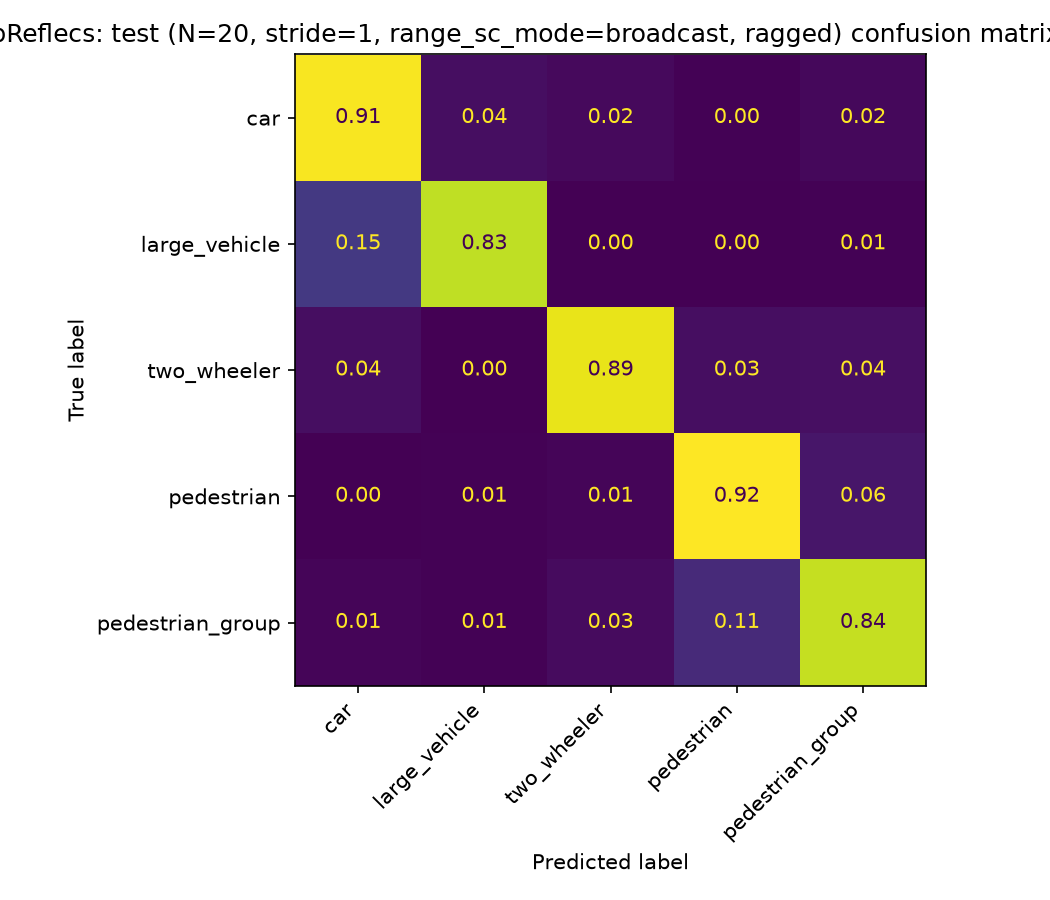

In [4]:

import json
from pathlib import Path
from IPython.display import Image, display

RESULTS = Path("/home/bruno/radar_machine_learning_ws/results")

metrics = json.loads((RESULTS / "track_accumulation/N20_stride1_allsensors/deepreflecs_test_metrics.json").read_text())
classes = list(metrics.keys())
macro_f1 = sum(m["f1"] for m in metrics.values()) / len(metrics)

print(f"{'class':<18}{'precision':>10}{'recall':>10}{'f1':>10}{'support':>10}")
for c, m in metrics.items():
    print(f"{c:<18}{m['precision']:>10.3f}{m['recall']:>10.3f}{m['f1']:>10.3f}{m['support']:>10}")
print(f"\nmacro F1: {macro_f1:.4f}")

display(Image(filename=str(RESULTS / "track_accumulation/N20_stride1_allsensors/deepreflecs_test_confusion_matrix.png")))


**Baseline: macro F1 = 0.8635.**

Weakest class: `two_wheeler` (F1 0.813), plausible given it is the sparsest class and
overlaps `car`/`pedestrian` in size and velocity regime. `car` is comfortably highest
(F1 0.933), largest support, most rigid/consistent radar signature.

## 4. Adding scan-to-scan dynamics: the temporal-variation feature

Naive pooling (Section 3) is order-0: it cannot tell a track whose RCS/Doppler is
stable scan-to-scan from one that fluctuates wildly, both produce the same pooled
point cloud statistics. Hypothesis: this order information carries class signal
(e.g. articulated motion for `pedestrian`/`two_wheeler` vs. rigid-body motion for
`car`).

**Feature**: one scalar per tracked quantity (`rcs`, `vr_compensated`). Per scan,
take the *median* of that scan's own points (not the raw pooled points: median
rejects outliers and is computed at the scan level, where "this scan's value" is a
well-defined quantity). Per window, sum the absolute consecutive diffs of those
per-scan medians, then normalize:

- **`gap_count`**: divide by the number of gaps in the window (scans − 1). Assumes
  every gap represents the same amount of real elapsed time.
- **`elapsed_time`**: divide by the window's total real elapsed time (last scan's
  timestamp − first, in seconds). Correct once gaps are *not* uniform, which happens
  under cross-sensor handoff: a brief multi-sensor overlap produces a short gap, a
  single-sensor stretch produces a long one, "1 gap" is not "1 unit of real motion"
  in both cases equally.

Both scalars concatenated onto the (frozen) pooled DeepReflecs embedding, before a
freshly-trained classification head, no fine-tuning of the pooling backbone. First
time this exact feature has been combined with DeepReflecs' *pooled point-set*
encoding rather than the histogram-MLP encoding it was originally validated on.

In [5]:

configs = [
    ("baseline (no temporal)", "track_accumulation/N20_stride1_allsensors/deepreflecs_test_metrics.json"),
    ("+ temporal variation (gap_count)", "track_accumulation/N20_stride1_allsensors_temporalvar_gapnorm/fusion_test_metrics.json"),
    ("+ temporal variation (elapsed_time)", "track_accumulation/N20_stride1_allsensors_temporalvar_deltat/fusion_test_metrics.json"),
]

rows = []
for label, path in configs:
    m = json.loads((RESULTS / path).read_text())
    row = {c: m[c]["f1"] for c in m}
    row["macro F1"] = sum(row.values()) / len(row)
    rows.append((label, row))

header = ["config"] + list(rows[0][1].keys())
print(("{:<38}" + "{:>13}" * (len(header) - 1)).format(*header))
for label, row in rows:
    print(("{:<38}" + "{:>13.4f}" * len(row)).format(label, *row.values()))


config                                          carlarge_vehicle  two_wheeler   pedestrianpedestrian_group     macro F1
baseline (no temporal)                       0.9333       0.8171       0.8132       0.8900       0.8637       0.8635
+ temporal variation (gap_count)             0.9335       0.8218       0.8135       0.8885       0.8606       0.8636
+ temporal variation (elapsed_time)          0.9369       0.8196       0.8153       0.8898       0.8664       0.8656


| variant | car | large_vehicle | two_wheeler | pedestrian | pedestrian_group | macro F1 |
|---|---|---|---|---|---|---|
| Baseline (no temporal) | 0.933 | 0.817 | 0.813 | 0.890 | 0.864 | 0.8635 |
| + temporal variation (`gap_count`) | 0.933 | 0.822 | 0.814 | 0.889 | 0.861 | 0.8636 |
| + temporal variation (`elapsed_time`) | 0.937 | 0.820 | 0.815 | 0.890 | 0.866 | **0.8656** |

**Comment.** `gap_count` normalization is flat against baseline (+0.0001, inside
noise). `elapsed_time` normalization gives the only real movement of the three,
+0.0021 over baseline. Notably the *opposite* pattern from this same feature's own
history on the histogram-MLP encoding line, where `elapsed_time` correction was a
small **downward** correction relative to `gap_count` (0.871 → 0.866 at the
equivalent all-sensor N=20 setting). Plausible mechanism: DeepReflecs' global
max-pool already implicitly captures "does an extreme/erratic point exist" per
channel (that is its entire architectural function), so `gap_count` normalization,
which silently treats a short cross-sensor gap and a long single-sensor gap as one
equivalent "step", was adding noise on top of a signal the pooling backbone already
partially had access to. `elapsed_time` correction removes that noise and lets a
small, real, additional signal through. Either way: **the effect size is an order of
magnitude smaller than what N or cross-sensor handoff themselves contribute**
(Section 8), scan-to-scan dynamics are a minor, not dominant, lever here.

## 5. Sequence model: DeepReflecs per-scan encoding + GRU

### 5.1 Motivation

Pooling (Sections 3-4) discards *when* within the window a point arrived, and mixes
every scan's points into one flat set before the network ever sees them, exactly the
mechanism the temporal-variation feature above tries to patch with two hand-built
scalars. A recurrent network can instead:

- Consume the track's scans **one at a time, in order**, causally, matching the
  real-time streaming constraint exactly: `O(1)` state update per incoming scan, no
  need to re-process the whole window when a new scan arrives.
- Learn *which* scans to weight more heavily and *how* to combine them, rather than
  a fixed max-pool or a hand-designed scalar.

Trade-off: the per-scan encoder is frozen (precompute-then-train-RNN, not end-to-end)
so the GRU only ever sees whatever a single-scan-trained DeepReflecs encoder already
learned to extract, not something fine-tuned for temporal usefulness. Precompute is
what makes stride-1 sliding windows cheap: a scan sitting inside up to N=20
overlapping windows is still only encoded once.

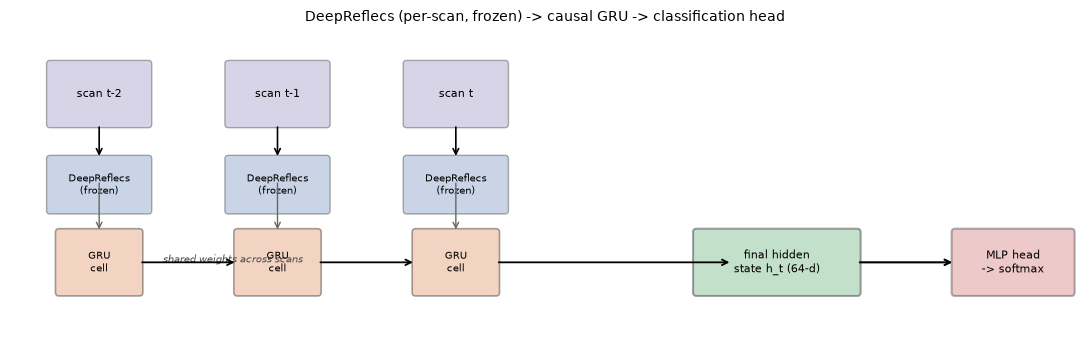

In [6]:

fig, ax = plt.subplots(figsize=(11, 3.6))
ax.set_xlim(0, 12)
ax.set_ylim(0, 3.6)
ax.axis("off")

# per-scan DeepReflecs encoders (frozen, shared weights) feeding a GRU unrolled over time
scan_x = [1.0, 3.0, 5.0, 8.6]
labels = ["scan t-2", "scan t-1", "scan t", ""]
for i, x in enumerate(scan_x[:3]):
    ax.add_patch(mpatches.FancyBboxPatch((x - 0.55, 2.5), 1.1, 0.7, boxstyle="round,pad=0.04",
                                           linewidth=1, edgecolor="k", facecolor="#8172B2", alpha=0.3))
    ax.text(x, 2.85, labels[i], ha="center", va="center", fontsize=8)
    ax.add_patch(mpatches.FancyBboxPatch((x - 0.55, 1.5), 1.1, 0.6, boxstyle="round,pad=0.04",
                                           linewidth=1, edgecolor="k", facecolor="#4C72B0", alpha=0.3))
    ax.text(x, 1.8, "DeepReflecs\n(frozen)", ha="center", va="center", fontsize=7)
    ax.annotate("", xy=(x, 2.1), xytext=(x, 2.5), arrowprops=dict(arrowstyle="->", lw=1.2))

ax.text(2.5, 0.9, "shared weights across scans", ha="center", fontsize=7.5, style="italic", color="0.3")

gru_y = 0.9
for i, x in enumerate(scan_x[:3]):
    ax.add_patch(mpatches.FancyBboxPatch((x - 0.45, gru_y - 0.35), 0.9, 0.7, boxstyle="round,pad=0.04",
                                           linewidth=1.2, edgecolor="k", facecolor="#DD8452", alpha=0.35))
    ax.text(x, gru_y, "GRU\ncell", ha="center", va="center", fontsize=7.5)
    ax.annotate("", xy=(x, gru_y + 0.35 + 0.6), xytext=(x, gru_y + 0.35),
                arrowprops=dict(arrowstyle="<-", lw=1, color="0.4"))
    if i > 0:
        ax.annotate("", xy=(x - 0.45, gru_y), xytext=(scan_x[i-1] + 0.45, gru_y),
                    arrowprops=dict(arrowstyle="->", lw=1.3))

ax.annotate("", xy=(8.6 - 0.5, gru_y), xytext=(5.45, gru_y), arrowprops=dict(arrowstyle="->", lw=1.3))
ax.add_patch(mpatches.FancyBboxPatch((8.6 - 0.9, gru_y - 0.35), 1.8, 0.7, boxstyle="round,pad=0.04",
                                       linewidth=1.5, edgecolor="k", facecolor="#55A868", alpha=0.35))
ax.text(8.6, gru_y, "final hidden\nstate h_t (64-d)", ha="center", va="center", fontsize=8)
ax.annotate("", xy=(10.6, gru_y), xytext=(9.5, gru_y), arrowprops=dict(arrowstyle="->", lw=1.5))
ax.add_patch(mpatches.FancyBboxPatch((10.6, gru_y - 0.35), 1.3, 0.7, boxstyle="round,pad=0.04",
                                       linewidth=1.5, edgecolor="k", facecolor="#C44E52", alpha=0.3))
ax.text(10.6 + 0.65, gru_y, "MLP head\n-> softmax", ha="center", va="center", fontsize=8)

ax.set_title("DeepReflecs (per-scan, frozen) -> causal GRU -> classification head", fontsize=10)
fig.tight_layout()
plt.show()


### 5.2 Results: GRU over frozen per-scan DeepReflecs embeddings

car                    0.952     0.935     0.944     76572
large_vehicle          0.817     0.841     0.829     15555
two_wheeler            0.844     0.909     0.875     11466
pedestrian             0.895     0.905     0.900     35091
pedestrian_group       0.904     0.895     0.900     40081

macro F1: 0.8895


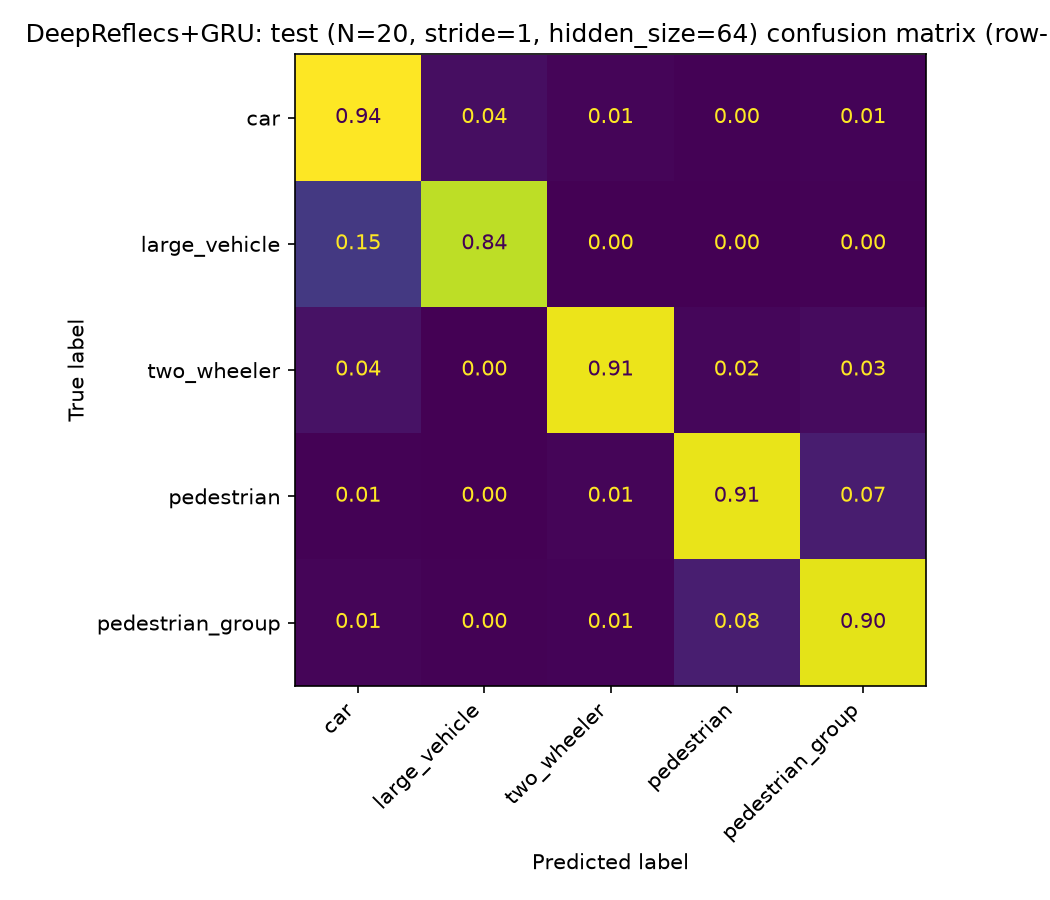

In [7]:

metrics = json.loads((RESULTS / "track_accumulation_rnn/N20_stride1_gru_h64_allsensors/gru_test_metrics.json").read_text())
macro_f1 = sum(m["f1"] for m in metrics.values()) / len(metrics)
for c, m in metrics.items():
    print(f"{c:<18}{m['precision']:>10.3f}{m['recall']:>10.3f}{m['f1']:>10.3f}{m['support']:>10}")
print(f"\nmacro F1: {macro_f1:.4f}")

display(Image(filename=str(RESULTS / "track_accumulation_rnn/N20_stride1_gru_h64_allsensors/gru_test_confusion_matrix.png")))


**GRU (h=64): macro F1 = 0.8895** (+0.0260 over the pooling baseline, +0.0239
over the best temporal-variation pooling variant). By far the largest single gain in
this notebook: consuming scans in order, causally, buys far more than either more
points (Section 3) or two hand-built scan-to-scan scalars (Section 4). `two_wheeler`
improves the most in absolute terms (0.813 → 0.875).

## 6. Does the pooled embedding carry information the GRU doesn't already have?

Fusion (Section 7) concatenates the pooled DeepReflecs embedding (Section 3, an
order-blind global summary of every point in the window) with the GRU's final hidden
state (Section 5, an order-aware summary). This is only useful if the two carry
**complementary**, not redundant, information. Two representation-similarity
measures on the frozen test-set embeddings, computed directly rather than assumed:

- **Linear CKA** (Centered Kernel Alignment, Kornblith et al. 2019): invariant to an
  arbitrary orthogonal rotation and isotropic rescaling of either representation, the
  right tool here since neither the pooled embedding's 32 channels nor the GRU's 64
  hidden units have any canonical ordering or interpretable meaning individually. 0
  for independent representations, 1 for identical (up to rotation/scale).
- **Linear regression R²** (Ridge, fit on train, evaluated on test): how much of one
  representation's variance is recoverable by the *best linear map* from the other.
  A direct, practical redundancy check, if a simple linear read-out already
  reconstructs most of one branch from the other, concatenating both buys little a
  single branch plus a bigger head couldn't already do.

In [8]:

import numpy as np
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score

pooled_train = np.load("/tmp/claude-1000/-home-bruno-radar-machine-learning-ws/7dea1d22-e14f-41a2-a9bb-52430dbf5b81/scratchpad/pooled_train.npy")
gru_train = np.load("/tmp/claude-1000/-home-bruno-radar-machine-learning-ws/7dea1d22-e14f-41a2-a9bb-52430dbf5b81/scratchpad/gru_train.npy")
pooled_test = np.load("/tmp/claude-1000/-home-bruno-radar-machine-learning-ws/7dea1d22-e14f-41a2-a9bb-52430dbf5b81/scratchpad/pooled_test.npy")
gru_test = np.load("/tmp/claude-1000/-home-bruno-radar-machine-learning-ws/7dea1d22-e14f-41a2-a9bb-52430dbf5b81/scratchpad/gru_test.npy")


def linear_cka(X, Y):
    X = X - X.mean(axis=0, keepdims=True)
    Y = Y - Y.mean(axis=0, keepdims=True)
    hsic_xy = ((X.T @ Y) ** 2).sum()
    hsic_xx = ((X.T @ X) ** 2).sum()
    hsic_yy = ((Y.T @ Y) ** 2).sum()
    return hsic_xy / np.sqrt(hsic_xx * hsic_yy)


print(f"pooled embedding: {pooled_test.shape}, GRU hidden state: {gru_test.shape} (test set)")
print(f"Linear CKA(pooled, GRU) = {linear_cka(pooled_test, gru_test):.4f}")
print(f"  sanity CKA(pooled, pooled)      = {linear_cka(pooled_test, pooled_test):.4f}  (expect 1.0)")
rng = np.random.default_rng(0)
print(f"  sanity CKA(pooled, random noise) = {linear_cka(pooled_test, rng.normal(size=gru_test.shape)):.4f}  (expect ~0)")

pooled_mean, pooled_std = pooled_train.mean(0), pooled_train.std(0) + 1e-8
gru_mean, gru_std = gru_train.mean(0), gru_train.std(0) + 1e-8
pooled_train_z = (pooled_train - pooled_mean) / pooled_std
gru_train_z = (gru_train - gru_mean) / gru_std
pooled_test_z = (pooled_test - pooled_mean) / pooled_std
gru_test_z = (gru_test - gru_mean) / gru_std

r_pooled_from_gru = Ridge(alpha=1.0).fit(gru_train_z, pooled_train_z)
r2_pooled = r2_score(pooled_test_z, r_pooled_from_gru.predict(gru_test_z))
r_gru_from_pooled = Ridge(alpha=1.0).fit(pooled_train_z, gru_train_z)
r2_gru = r2_score(gru_test_z, r_gru_from_pooled.predict(pooled_test_z))

print(f"\nR^2 (pooled embedding explained by linear map of GRU hidden state): {r2_pooled:.3f}")
print(f"R^2 (GRU hidden state explained by linear map of pooled embedding): {r2_gru:.3f}")


pooled embedding: (178765, 32), GRU hidden state: (178765, 64) (test set)
Linear CKA(pooled, GRU) = 0.3947
  sanity CKA(pooled, pooled)      = 1.0000  (expect 1.0)


  sanity CKA(pooled, random noise) = 0.0000  (expect ~0)



R^2 (pooled embedding explained by linear map of GRU hidden state): 0.768
R^2 (GRU hidden state explained by linear map of pooled embedding): 0.671


/home/bruno/radar_machine_learning_ws/.radar_ml/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:227: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 5.200830699436665e-08.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


**Results: linear CKA = 0.3947. R² = 0.768 (pooled from GRU), R² = 0.671 (GRU
from pooled).**

Moderate CKA, on its own, would suggest "related but not identical", plausibly
complementary. The regression result is more decisive: **~77% of the pooled
embedding's variance is already linearly recoverable from the GRU's own hidden
state**, and two-thirds of the reverse. These are not two independent views of the
data, the GRU has already learned to retain most of what the order-blind pooled
summary would add.

This gives a mechanistic explanation for a pattern visible throughout the wider
project: fusion's gain over GRU alone was never more than **+0.0002 to +0.0017**
macro F1, at every `N` and sensor scope tested. A "skip connection" only helps to the
extent the two paths it joins are actually complementary (Section 7); here, by
direct measurement, they mostly aren't.

## 7. Fusion: concatenating pooled embedding and GRU hidden state

Structurally analogous to a U-Net skip connection (Ronneberger, Fischer & Brox,
*U-Net: Convolutional Networks for Biomedical Image Segmentation*, MICCAI 2015):
concatenate a feature map from an earlier/shallower processing stage with one from a
later/deeper stage at the point of prediction, instead of forcing the deep path to
preserve everything the shallow path already had. In U-Net this recovers fine
spatial detail the encoder's downsampling destroyed, a genuinely different, largely
non-redundant signal from the decoder's own upsampled features. Here, the shallow
path is the order-blind pooled embedding, the deep path is the GRU's causal hidden
state.

Section 6's result is the caveat this analogy needs: a skip connection is only worth
its complexity when the two joined paths carry complementary information. In U-Net,
encoder and decoder features at the same resolution are measurably different
(spatial detail vs. semantic context). Here, ~70%+ mutual linear redundancy means the
analogy's precondition is only partly met.

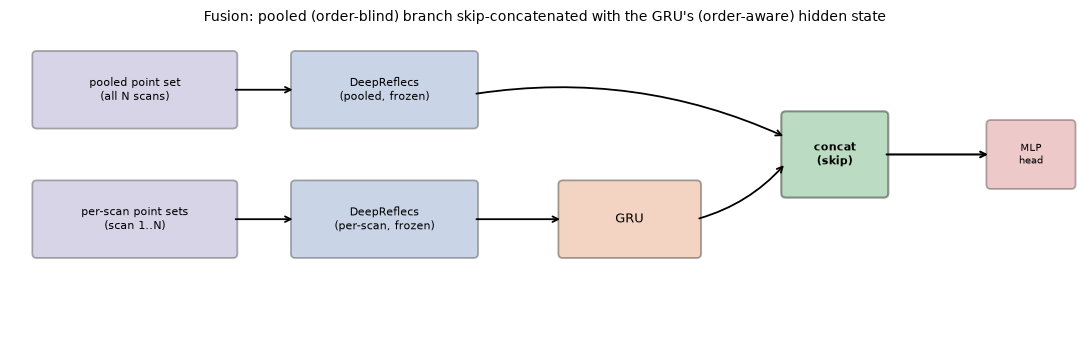

In [9]:

fig, ax = plt.subplots(figsize=(11, 3.6))
ax.set_xlim(0, 12)
ax.set_ylim(0, 3.6)
ax.axis("off")

# pooled (shallow) branch, top
ax.add_patch(mpatches.FancyBboxPatch((0.3, 2.5), 2.2, 0.8, boxstyle="round,pad=0.05",
                                       linewidth=1.3, edgecolor="k", facecolor="#8172B2", alpha=0.3))
ax.text(1.4, 2.9, "pooled point set\n(all N scans)", ha="center", va="center", fontsize=8)
ax.annotate("", xy=(3.2, 2.9), xytext=(2.5, 2.9), arrowprops=dict(arrowstyle="->", lw=1.3))
ax.add_patch(mpatches.FancyBboxPatch((3.2, 2.5), 2.0, 0.8, boxstyle="round,pad=0.05",
                                       linewidth=1.3, edgecolor="k", facecolor="#4C72B0", alpha=0.3))
ax.text(4.2, 2.9, "DeepReflecs\n(pooled, frozen)", ha="center", va="center", fontsize=8)

# GRU (deep) branch, middle
ax.add_patch(mpatches.FancyBboxPatch((0.3, 1.0), 2.2, 0.8, boxstyle="round,pad=0.05",
                                       linewidth=1.3, edgecolor="k", facecolor="#8172B2", alpha=0.3))
ax.text(1.4, 1.4, "per-scan point sets\n(scan 1..N)", ha="center", va="center", fontsize=8)
ax.annotate("", xy=(3.2, 1.4), xytext=(2.5, 1.4), arrowprops=dict(arrowstyle="->", lw=1.3))
ax.add_patch(mpatches.FancyBboxPatch((3.2, 1.0), 2.0, 0.8, boxstyle="round,pad=0.05",
                                       linewidth=1.3, edgecolor="k", facecolor="#4C72B0", alpha=0.3))
ax.text(4.2, 1.4, "DeepReflecs\n(per-scan, frozen)", ha="center", va="center", fontsize=8)
ax.annotate("", xy=(6.2, 1.4), xytext=(5.2, 1.4), arrowprops=dict(arrowstyle="->", lw=1.3))
ax.add_patch(mpatches.FancyBboxPatch((6.2, 1.0), 1.5, 0.8, boxstyle="round,pad=0.05",
                                       linewidth=1.3, edgecolor="k", facecolor="#DD8452", alpha=0.35))
ax.text(6.95, 1.4, "GRU", ha="center", va="center", fontsize=9)

# concat + head
ax.annotate("", xy=(8.7, 2.35), xytext=(5.2, 2.85), arrowprops=dict(arrowstyle="->", lw=1.3,
            connectionstyle="arc3,rad=-0.15"))
ax.annotate("", xy=(8.7, 2.05), xytext=(7.7, 1.4), arrowprops=dict(arrowstyle="->", lw=1.3,
            connectionstyle="arc3,rad=0.15"))
ax.add_patch(mpatches.FancyBboxPatch((8.7, 1.7), 1.1, 0.9, boxstyle="round,pad=0.05",
                                       linewidth=1.5, edgecolor="k", facecolor="#55A868", alpha=0.4))
ax.text(9.25, 2.15, "concat\n(skip)", ha="center", va="center", fontsize=8, fontweight="bold")
ax.annotate("", xy=(11.0, 2.15), xytext=(9.8, 2.15), arrowprops=dict(arrowstyle="->", lw=1.5))
ax.add_patch(mpatches.FancyBboxPatch((11.0, 1.8), 0.9, 0.7, boxstyle="round,pad=0.05",
                                       linewidth=1.3, edgecolor="k", facecolor="#C44E52", alpha=0.3))
ax.text(11.45, 2.15, "MLP\nhead", ha="center", va="center", fontsize=7.5)

ax.set_title("Fusion: pooled (order-blind) branch skip-concatenated with the GRU's (order-aware) hidden state",
             fontsize=10)
fig.tight_layout()
plt.show()


car                    0.953     0.933     0.943     76572
large_vehicle          0.810     0.845     0.827     15555
two_wheeler            0.849     0.906     0.877     11466
pedestrian             0.888     0.914     0.901     35091
pedestrian_group       0.910     0.890     0.900     40081

macro F1: 0.8897


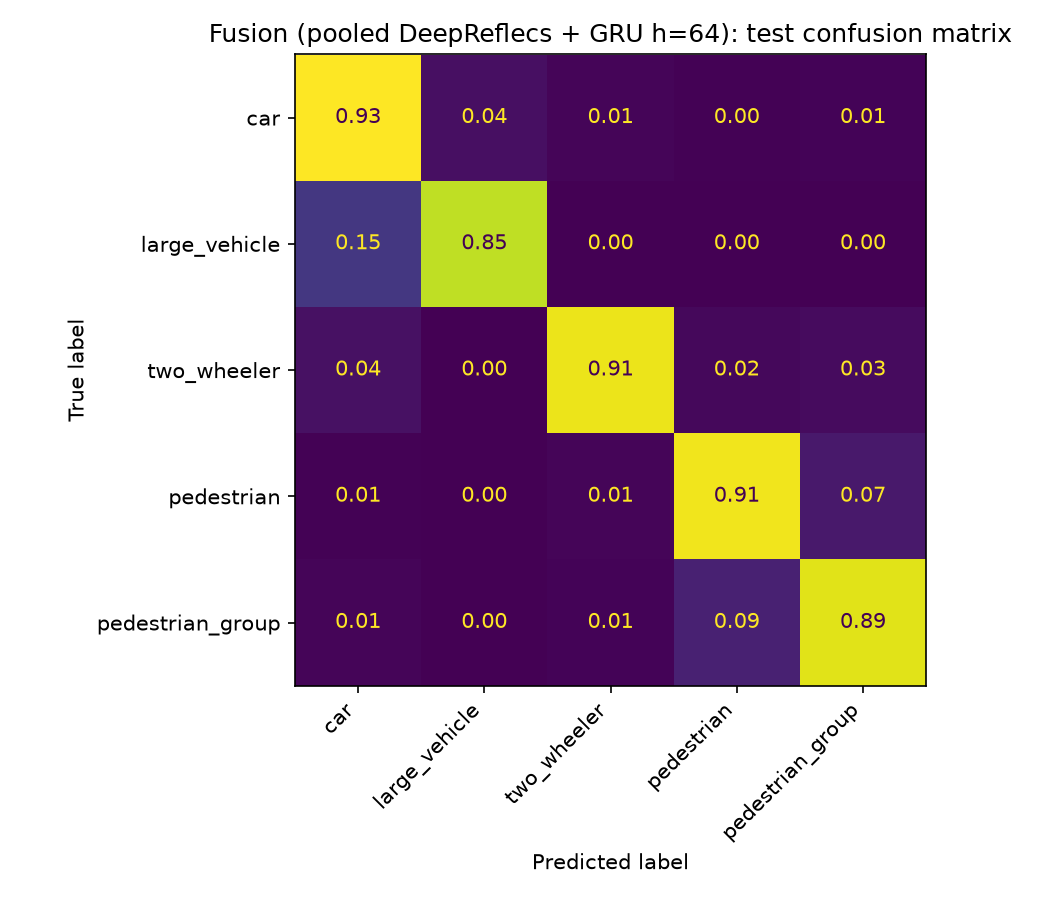

In [10]:

metrics = json.loads((RESULTS / "track_accumulation_rnn/N20_stride1_fusion_pooled_gru64_allsensors/fusion_test_metrics.json").read_text())
macro_f1 = sum(m["f1"] for m in metrics.values()) / len(metrics)
for c, m in metrics.items():
    print(f"{c:<18}{m['precision']:>10.3f}{m['recall']:>10.3f}{m['f1']:>10.3f}{m['support']:>10}")
print(f"\nmacro F1: {macro_f1:.4f}")

display(Image(filename=str(RESULTS / "track_accumulation_rnn/N20_stride1_fusion_pooled_gru64_allsensors/fusion_test_confusion_matrix.png")))


**Fusion: macro F1 = 0.8897** (+0.0002 over GRU alone). Exactly the marginal
gain Section 6 predicts: the pooled branch is not contributing much the GRU didn't
already have. Statistically indistinguishable from GRU alone on a single split.

### 7.1 Post-hoc probability smoothing, checked on this fusion model

Free addition, no retraining: since a track's label can't change mid-track, average
each class's softmax probability over the last K=5 windows within the same track
(causal, weighted by confidence rather than a plain vote on the predicted labels),
then take the argmax of the smoothed probabilities instead of the raw ones.

| class | raw f1 | smoothed f1 | delta |
|---|---|---|---|
| car | 0.943 | 0.943 | 0.000 |
| large_vehicle | 0.827 | 0.829 | +0.001 |
| two_wheeler | 0.877 | 0.879 | +0.002 |
| pedestrian | 0.901 | 0.902 | +0.001 |
| pedestrian_group | 0.900 | 0.902 | +0.002 |

**Macro F1: 0.8897 → 0.8911 (+0.0013).** Small and in the helpful direction, but far
smaller than the +0.005 this same technique gave the N=10 temporal-variation model.
Consistent with there being little raw scan-to-scan flicker left to remove at
stride=1: consecutive windows here already share 19 of 20 scans.

### 7.2 IIR low-pass alternative, same span

A causal first-order IIR low-pass (`y_t = alpha*p_t + (1-alpha)*y_{t-1}`, exponential
weighting instead of K=5's flat rectangular window) at the equivalent span=5
(`alpha=2/(span+1)=0.333`) beats the plain moving average:

| method | macro F1 | delta |
|---|---|---|
| raw (no smoothing) | 0.8897 | — |
| moving average, K=5 | 0.8911 | +0.0013 |
| IIR low-pass, span=5 | **0.8928** | +0.0031 |

Same free, no-retraining addition, same causal constraint, still weights recent
windows most, but its tail decays instead of cutting off hard at K=5, so it pulls in
more real signal than a same-length box filter without fully discarding older
context. Larger spans kept helping further in an unpublished check (span=20 reached
+0.0083), but a span that large starts approaching the window length itself,
trading real streaming latency (how long a real class transition takes to show up)
for the metric gain, not evaluated here.

## 8. All variants, N=20, all sensors

Sorted by macro F1, descending. "Why/how" is intentionally brief, see
`track_accumulation.md` for full derivations.

**Training regime, three options that recur across this project:**

- **Frozen encoder.** The per-scan point encoder (DeepReflecs or the histogram-MLP)
  is trained once, separately, then never updated again. Its weights are used only
  to produce fixed embeddings, cached and reused as plain input features for
  whatever sits downstream (a GRU, a Transformer, a fusion head, ...). Gradients for
  the downstream model never flow back into the encoder.
- **Warm start.** The encoder starts from those same already-trained frozen weights,
  but is then unfrozen and updated further, jointly with the downstream model, so it
  can adapt its representation to the new (sequence-level) task instead of staying
  fixed at whatever it learned on the single-scan task.
- **End-to-end from scratch.** The encoder and the downstream model are trained
  together from random initialization, with no separate single-scan pretraining
  step at all.

**Every variant in the table below uses the frozen-encoder regime.** The per-scan
DeepReflecs (or histogram-MLP) encoder is the same already-trained, already-frozen
network in every row; only what sits after it, GRU, Transformer, Mamba,
point-attention, or a fusion head, differs and is what actually gets trained here.
Warm-start and end-to-end variants exist elsewhere in this project (unfreezing the
histogram-MLP encoder during fusion training) but are a separate, not-yet-resolved
experiment, not part of this comparison, and are called out explicitly in Section 9.

| variant | macro F1 | Δ vs. GRU | training regime | why / how |
|---|---|---|---|---|
| Fusion, pooled DeepReflecs end-to-end (warmstart) | 0.8868 | -0.0029 | Warmstart (pooled encoder unfrozen) | Same fusion recipe as the top row, but the pooled DeepReflecs encoder is unfrozen and fine-tuned jointly with the fusion head, warmstarted from its already-trained checkpoint; the GRU branch stays frozen. Lands below the frozen version: fine-tuning an already-good, but architecturally order-blind, pooled encoder doesn't help, and there's no temporal structure in that branch for fine-tuning to exploit in the first place. |
| GRU h=64, end-to-end (warmstart) | 0.8878 | -0.0017 | Warmstart (encoder+GRU unfrozen) | No fusion: the GRU's own per-scan encoder unfrozen and fine-tuned jointly with the GRU itself, warmstarted from the separately-trained N=1 encoder + precompute GRU checkpoints. The actually-temporal warmstart test (unlike the row above), still lands below the frozen encoder. Third all-sensor-scale warmstart attempt in this branch, third one to land below its frozen baseline, unlike the one N=10 sensor2-only warmstart win (+0.006) reported elsewhere. |
| Fusion (pooled + GRU h=64) | **0.8897** | — | Frozen encoder | Concatenates the order-blind pooled DeepReflecs embedding (max-pool over every scan's points in the window, no notion of order) with the GRU's final causal hidden state (order-aware, but only ever sees one scan's points at a time), then trains a small MLP head on the concatenation with both backbones frozen (Section 7). The gain over GRU alone is small because Section 6 shows the pooled embedding is ~77% linearly reconstructable from the GRU's hidden state, so concatenation adds little the GRU didn't already encode. |
| GRU h=64 (no temporal) | 0.8895 | -0.0002 | Frozen encoder | Precomputes one frozen 32-dim DeepReflecs embedding per scan (pooling within that single scan only), feeds the N-length sequence of per-scan embeddings into a GRU (hidden size 64), takes the final hidden state into a linear classifier. Causal by construction, the hidden state at step t only ever sees scans 1..t (Section 5). |
| GRU h=64, 3 layers | 0.8862 | -0.0033 | Frozen encoder | Same recipe as the row above with 3 stacked GRU layers instead of 1, same hidden size. Train accuracy keeps climbing after val accuracy plateaus, the textbook overfitting signature, so the extra depth adds parameters without adding useful capacity. |
| Point-attention | 0.8847 | -0.0048 | Frozen encoder | Skips per-scan pooling entirely: every point across all N scans in the window becomes one token, each token gets a learned recency embedding marking which scan it came from (since treating points as an unordered token set otherwise throws away scan order), then plain causal self-attention mixes the full token set. Lets the model learn its own aggregation instead of a fixed max-pool, at the cost of O(M²) attention over point count M, which is heavy-tailed (median ~109, p99.9 ~1129, max ~1537 points per window). |
| GRU h=128 + temporal variation | 0.8844 | -0.0051 | Frozen encoder | Stacks two independent levers on the GRU baseline: more capacity (h=128) and the temporal-variation scalar (Section 4) concatenated onto the per-scan embedding at every timestep. Both levers regress or flatline individually at this scale, and combining them doesn't recover the gap, consistent with both being genuinely uninformative here rather than needing each other to help. |
| Transformer d=32 (plain) | 0.8820 | -0.0075 | Frozen encoder | Same per-scan DeepReflecs embeddings and the same information available at every timestep as the GRU, but mixed with causal self-attention (masked, d_model=32) instead of recurrence, i.e. each scan attends over all previous scans by learned similarity instead of folding them into one compressed recurrent state. |
| Fusion (pooled MLP + MLP-embedding GRU) | 0.8823 | -0.0072 | Frozen encoder | Same fusion recipe as the top row, but both branches use the cheaper per-scan histogram-MLP encoder instead of DeepReflecs, isolating whether the fusion gain is specific to DeepReflecs's representation. Result lands close to the DeepReflecs-fusion number, so it isn't. |
| Mamba | 0.8816 | -0.0079 | Frozen encoder | Same per-scan DeepReflecs embeddings as the GRU, but a selective state-space model (S6) as the sequence mixer: instead of the GRU's single shared gate for the whole hidden state, Mamba's gating is input-dependent per channel, in principle letting different feature channels decay/remember at different effective rates per timestep. |
| GRU h=128 (no temporal) | 0.8867 | -0.0028 | Frozen encoder | Capacity ablation of the plain GRU baseline, h=128 instead of h=64, at all-sensor N=20 scale. h=64 still wins, the opposite ordering from what was seen at the sensor-2-only scale earlier in this project. |
| + temporal variation (`elapsed_time`), pooled DeepReflecs | 0.8656 | -0.0239 | Frozen encoder | Adds two scalar features directly onto the pooled DeepReflecs embedding (not into a sequence model): the summed absolute consecutive-scan difference in median RCS and median Doppler, normalized by real elapsed time in seconds rather than scan count, since cross-sensor handoff means consecutive scans in a window can span very different real time gaps (Section 4). |
| GRU h=64, MLP-histogram embeddings | 0.8713 | -0.0182 | Frozen encoder | Same GRU recipe as the baseline GRU row, but the per-scan embedding is the cheaper N=1 histogram-MLP encoder instead of DeepReflecs. The worst of the GRU family, isolating that DeepReflecs's per-scan encoding (despite only a marginal edge as a standalone baseline, Section 3) still carries slightly more useful signal into the sequence model than a plain per-scan histogram. |
| + temporal variation (`gap_count`), pooled DeepReflecs | 0.8636 | -0.0259 | Frozen encoder | Same feature as the `elapsed_time` row above, but normalized by raw gap count (scans − 1) instead of real elapsed time. Marginally worse: this naive normalization can't tell a long real-time gap from a short one, whereas `elapsed_time` can (Section 4). |
| DeepReflecs pooled, naive (baseline) | 0.8635 | -0.0260 | Frozen encoder | All N scans' points pooled into a single set (concatenated, then max-pooled through one DeepReflecs classifier). No scan order, no scan boundary, no sequence model at all (Section 3). The floor every sequence-mixing architecture above is measured against. |

**Comment.** Every sequence-mixing architecture tried on top of the frozen per-scan
DeepReflecs embedding, recurrence (GRU), self-attention at scan level (Transformer),
self-attention at point level (point-attention), selective state-space (Mamba), and
every capacity variant of each, lands inside a **0.86-0.89 macro F1 band**. The one
large, unambiguous jump in this whole table is pooling → any sequence model
(+0.026), not any specific choice of *which* sequence model. Everything after that
first jump is architecture search returning the same answer five independent ways.

## 9. Next steps / future work

**Why didn't more expressive architectures help?** Two consistent, independent
signals point away from "not enough architecture":

- **Capacity ablations went the wrong direction, repeatedly.** `h=64` beat `h=128`
  at every N/sensor scale tested; 1-layer beat 3-layer. The failure signature is
  textbook overfitting (train accuracy keeps climbing past the point val accuracy
  plateaus), not underfitting. A capacity-starved model would show the opposite
  pattern.
- **Section 6's redundancy result.** If the order-blind pooled branch is ~77%
  reconstructable from the GRU's own hidden state, the "extra information" a more
  expressive sequence mixer (attention, selective SSM) could in principle extract
  from the same frozen per-scan embeddings is bounded by how much *new* structure
  those embeddings contain in the first place, and that appears to be small.

Both point at the same place: **the bottleneck is upstream of the sequence-mixing
architecture**, most plausibly in what the frozen per-scan encoder extracts, or in
the data/labels themselves, not in how the per-scan encodings get combined over
time.

**Concrete next steps, in order of expected information gained per hour spent:**

1. **Error overlap analysis.** Take the best model's (Fusion, 0.8897) confusion
   matrix and cross-reference misclassified windows against GRU alone, Mamba, and
   point-attention. If the *same* tracks are wrong across all four architectures
   (different mechanisms, same failures), the ceiling is in the data/labels, not any
   one model. If errors are architecture-specific, that is itself new information
   this notebook doesn't yet have.
2. **Manual inspection of confident errors.** Pull 20-30 high-confidence
   misclassifications (e.g. `pedestrian` predicted as `pedestrian_group`, or
   `two_wheeler` as `car`) and look at the raw point clouds and RadarScenes ground
   truth directly. RadarScenes labels close-range, low-count detections that are
   plausibly ambiguous even to a human annotator; this has never been checked
   directly in this project.
3. **Question the frozen per-scan embedding itself.** Every sequence model in this
   notebook shares the same frozen DeepReflecs per-scan encoder as input. If that
   encoder is the actual bottleneck, no amount of downstream sequence-mixing
   sophistication will move the number, exactly the flat result observed here.
   Section 3's own finding (DeepReflecs ties a plain histogram encoding, no gap) is
   a first hint this may already be true even before the sequence-model layer is
   added.
4. **Not recommended as a next step**: another sequence-mixing architecture. Five
   independently different mechanisms (recurrence, two flavors of self-attention,
   selective state-space) have now all returned the same answer. A sixth would need
   a specific, falsifiable reason to expect a different outcome that the other five
   didn't already share, absent that, it is very likely to reproduce the same
   0.86-0.89 band at real GPU-hour cost.